Kategori A

Rata-rata GII per tingkat Human Development:
Human_development  Rata_rata_GII
        Very high       0.147032
             High       0.341690
           Medium       0.479472
              Low       0.593867


C:\Users\nanin\AppData\Local\Temp\ipykernel_12992\2822355485.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_gii, x='Human_development', y='Rata_rata_GII', palette=colors, ax=ax)


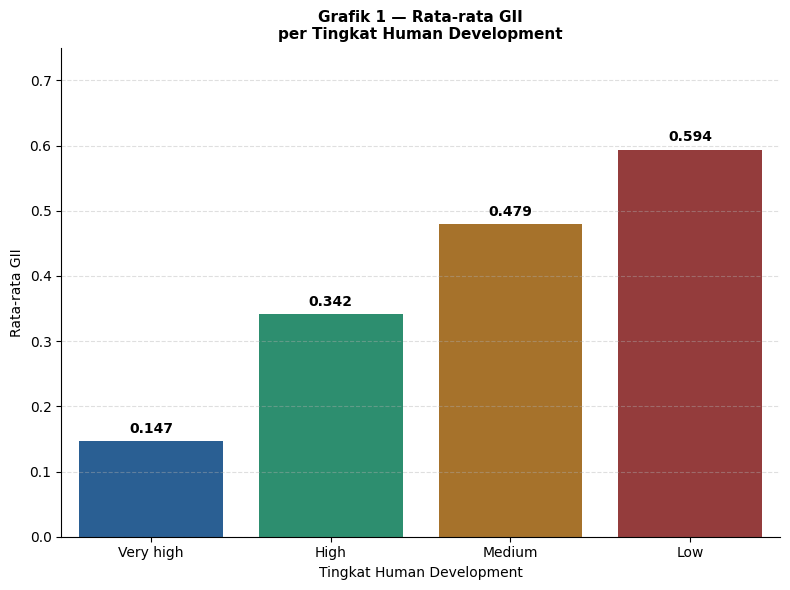

Grafik disimpan sebagai 'kategori_a_gii_bar_chart.png'


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('Kelas A_Gender Inequality Index.csv')

# Agregasi: rata-rata GII per Human_development
avg_gii = df.groupby('Human_development')['GII'].mean().reset_index()
avg_gii.columns = ['Human_development', 'Rata_rata_GII']

urutan = ['Very high', 'High', 'Medium', 'Low']
avg_gii['Human_development'] = pd.Categorical(
    avg_gii['Human_development'], categories=urutan, ordered=True
)
avg_gii = avg_gii.sort_values('Human_development')

print("Rata-rata GII per tingkat Human Development:")
print(avg_gii.to_string(index=False))

# GRAFIK 1 — Kategori A: Agregasi
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
ax = axes

colors = ['#185FA5', '#1D9E75', '#BA7517', '#A32D2D']
sns.barplot(data=avg_gii, x='Human_development', y='Rata_rata_GII', palette=colors, ax=ax)

for bar, val in zip(ax.patches, avg_gii['Rata_rata_GII']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Grafik 1 — Rata-rata GII\nper Tingkat Human Development', fontsize=11, fontweight='bold')
ax.set_xlabel('Tingkat Human Development', fontsize=10)
ax.set_ylabel('Rata-rata GII', fontsize=10)
ax.set_ylim(0, 0.75)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('kategori_a_gii_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan sebagai 'kategori_a_gii_bar_chart.png'")

Kategori B

5 Negara 'Very High' dengan Maternal Mortality Terendah:
Country  Maternal_mortality
 Norway                 2.0
  Italy                 2.0
 Poland                 2.0
Belarus                 2.0
Finland                 3.0


C:\Users\nanin\AppData\Local\Temp\ipykernel_12992\3173326725.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, x='Maternal_mortality', y='Country', palette=colors, ax=ax, orient='h')


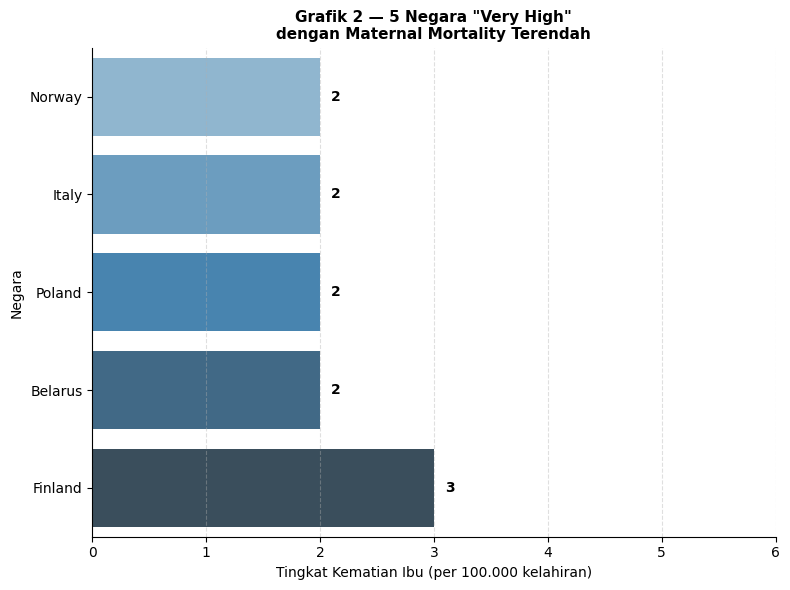

Grafik disimpan sebagai 'kategori_b_maternal_mortality.png'


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('Kelas A_Gender Inequality Index.csv')

# Filter: 5 negara Very high dengan Maternal_mortality terendah
very_high = df[df['Human_development'] == 'Very high'].dropna(subset=['Maternal_mortality'])
top5 = very_high.nsmallest(5, 'Maternal_mortality')[['Country', 'Maternal_mortality']]
top5 = top5.sort_values('Maternal_mortality', ascending=True)

print("5 Negara 'Very High' dengan Maternal Mortality Terendah:")
print(top5.to_string(index=False))

# GRAFIK 2 — Kategori B: Filter/Tren
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
ax = axes

colors = sns.color_palette('Blues_d', n_colors=5)
sns.barplot(data=top5, x='Maternal_mortality', y='Country', palette=colors, ax=ax, orient='h')

for bar, val in zip(ax.patches, top5['Maternal_mortality']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{int(val)}', ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_title('Grafik 2 — 5 Negara "Very High"\ndengan Maternal Mortality Terendah', fontsize=11, fontweight='bold')
ax.set_xlabel('Tingkat Kematian Ibu (per 100.000 kelahiran)', fontsize=10)
ax.set_ylabel('Negara', fontsize=10)
ax.set_xlim(0, top5['Maternal_mortality'].max() + 3)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('kategori_b_maternal_mortality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan sebagai 'kategori_b_maternal_mortality.png'")

Kategori C

Korelasi F_secondary_educ vs Adolescent_birth_rate:
                       F_secondary_educ  Adolescent_birth_rate
F_secondary_educ               1.000000              -0.721819
Adolescent_birth_rate         -0.721819               1.000000


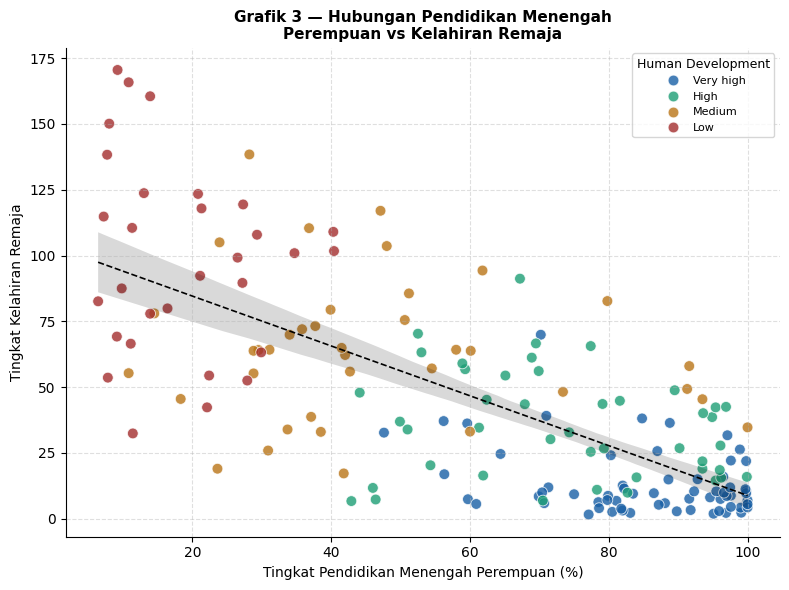

Grafik disimpan sebagai 'kategori_c_korelasi.png'


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('Kelas A_Gender Inequality Index.csv')

# Korelasi: F_secondary_educ vs Adolescent_birth_rate
korelasi = df[['F_secondary_educ', 'Adolescent_birth_rate', 'Human_development']].dropna()

print("Korelasi F_secondary_educ vs Adolescent_birth_rate:")
print(korelasi[['F_secondary_educ', 'Adolescent_birth_rate']].corr())

# GRAFIK 3 — Kategori C: Korelasi
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
ax = axes

urutan = ['Very high', 'High', 'Medium', 'Low']
palette = {'Very high': '#185FA5', 'High': '#1D9E75', 'Medium': '#BA7517', 'Low': '#A32D2D'}

sns.scatterplot(data=korelasi, x='F_secondary_educ', y='Adolescent_birth_rate',
                hue='Human_development', hue_order=urutan, palette=palette, ax=ax, s=60, alpha=0.8)
sns.regplot(data=korelasi, x='F_secondary_educ', y='Adolescent_birth_rate',
            scatter=False, ax=ax, color='black', line_kws={'linestyle': '--', 'linewidth': 1.2})

ax.set_title('Grafik 3 — Hubungan Pendidikan Menengah\nPerempuan vs Kelahiran Remaja', fontsize=11, fontweight='bold')
ax.set_xlabel('Tingkat Pendidikan Menengah Perempuan (%)', fontsize=10)
ax.set_ylabel('Tingkat Kelahiran Remaja', fontsize=10)
ax.grid(linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='Human Development', fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig('kategori_c_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan sebagai 'kategori_c_korelasi.png'")

Kategori D 

Statistik Deskriptif Adolescent_birth_rate:
                   count       mean        std   min     25%    50%      75%  \
Human_development                                                              
High                49.0  35.997959  19.410516   6.7  19.000  34.60   47.900   
Low                 32.0  95.143750  38.116849  22.7  65.975  95.75  118.275   
Medium              44.0  64.459091  28.445577  17.2  45.475  63.00   76.125   
Very high           66.0  12.907576  12.470535   1.6   5.325   8.75   14.975   

                     max  
Human_development         
High                91.2  
Low                170.5  
Medium             139.7  
Very high           69.9  


C:\Users\nanin\AppData\Local\Temp\ipykernel_12992\250281582.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=distribusi, x='Human_development', y='Adolescent_birth_rate',


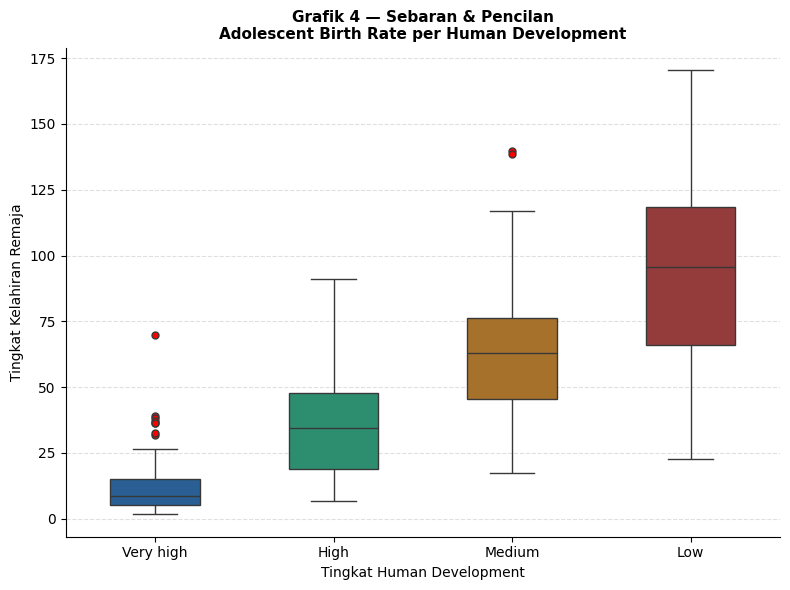

Grafik disimpan sebagai 'kategori_d_distribusi.png'


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('Kelas A_Gender Inequality Index.csv')

# Distribusi: sebaran Adolescent_birth_rate per Human_development
distribusi = df[['Human_development', 'Adolescent_birth_rate']].dropna()

print("Statistik Deskriptif Adolescent_birth_rate:")
print(distribusi.groupby('Human_development')['Adolescent_birth_rate'].describe())

# GRAFIK 4 — Kategori D: Distribusi
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
ax = axes

urutan = ['Very high', 'High', 'Medium', 'Low']
palette = {'Very high': '#185FA5', 'High': '#1D9E75', 'Medium': '#BA7517', 'Low': '#A32D2D'}

sns.boxplot(data=distribusi, x='Human_development', y='Adolescent_birth_rate',
            order=urutan, palette=palette, ax=ax, width=0.5,
            flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))

ax.set_title('Grafik 4 — Sebaran & Pencilan\nAdolescent Birth Rate per Human Development', fontsize=11, fontweight='bold')
ax.set_xlabel('Tingkat Human Development', fontsize=10)
ax.set_ylabel('Tingkat Kelahiran Remaja', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('kategori_d_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan sebagai 'kategori_d_distribusi.png'")

Grafik 5 (Gabungan)

C:\Users\nanin\AppData\Local\Temp\ipykernel_12992\1224471906.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_gii, x='Human_development', y='Rata_rata_GII', palette=colors_a, ax=ax)
C:\Users\nanin\AppData\Local\Temp\ipykernel_12992\1224471906.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, x='Maternal_mortality', y='Country', palette=colors_b, ax=ax, orient='h')
C:\Users\nanin\AppData\Local\Temp\ipykernel_12992\1224471906.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=distribusi, x='Human_development',

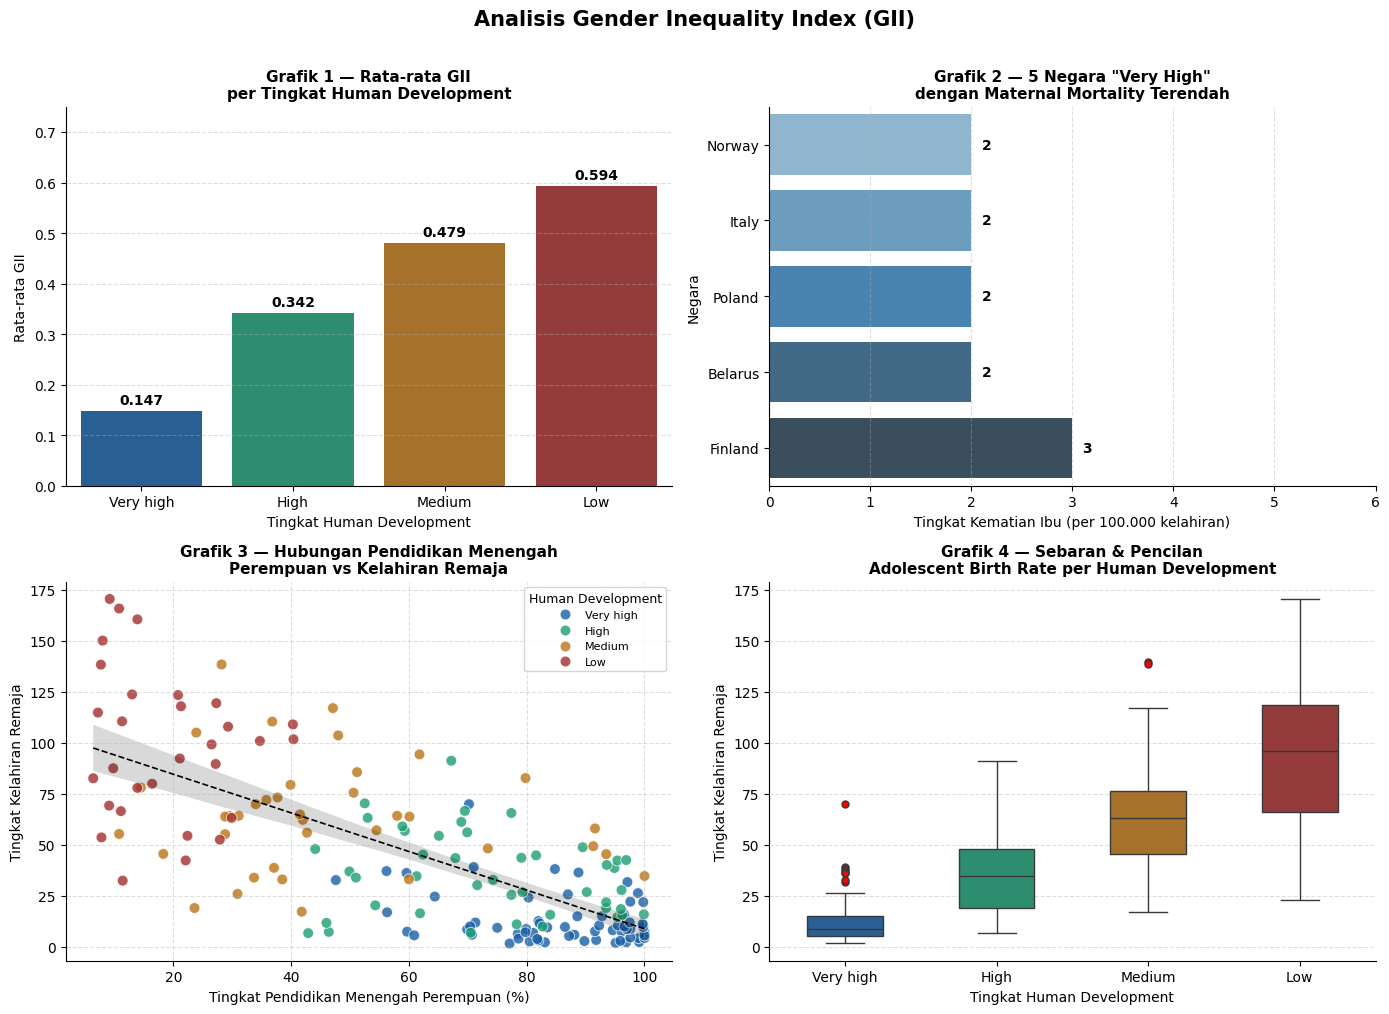

Grafik disimpan sebagai 'grafik5_gabungan.png'


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('Kelas A_Gender Inequality Index.csv')

# ── Data Kategori A ──────────────────────────────────────────────────────────
avg_gii = df.groupby('Human_development')['GII'].mean().reset_index()
avg_gii.columns = ['Human_development', 'Rata_rata_GII']
urutan = ['Very high', 'High', 'Medium', 'Low']
avg_gii['Human_development'] = pd.Categorical(avg_gii['Human_development'], categories=urutan, ordered=True)
avg_gii = avg_gii.sort_values('Human_development')

# ── Data Kategori B ──────────────────────────────────────────────────────────
very_high = df[df['Human_development'] == 'Very high'].dropna(subset=['Maternal_mortality'])
top5 = very_high.nsmallest(5, 'Maternal_mortality')[['Country', 'Maternal_mortality']]
top5 = top5.sort_values('Maternal_mortality', ascending=True)

# ── Data Kategori C ──────────────────────────────────────────────────────────
korelasi = df[['F_secondary_educ', 'Adolescent_birth_rate', 'Human_development']].dropna()

# ── Data Kategori D ──────────────────────────────────────────────────────────
distribusi = df[['Human_development', 'Adolescent_birth_rate']].dropna()

# ── Figure Gabungan 2x2 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analisis Gender Inequality Index (GII)', fontsize=15, fontweight='bold', y=1.01)

palette = {'Very high': '#185FA5', 'High': '#1D9E75', 'Medium': '#BA7517', 'Low': '#A32D2D'}

# ── GRAFIK 1 — Kategori A: Agregasi (axes[0, 0]) ────────────────────────────
ax = axes[0, 0]
colors_a = ['#185FA5', '#1D9E75', '#BA7517', '#A32D2D']
sns.barplot(data=avg_gii, x='Human_development', y='Rata_rata_GII', palette=colors_a, ax=ax)
for bar, val in zip(ax.patches, avg_gii['Rata_rata_GII']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Grafik 1 — Rata-rata GII\nper Tingkat Human Development', fontsize=11, fontweight='bold')
ax.set_xlabel('Tingkat Human Development', fontsize=10)
ax.set_ylabel('Rata-rata GII', fontsize=10)
ax.set_ylim(0, 0.75)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

# ── GRAFIK 2 — Kategori B: Filter/Tren (axes[0, 1]) ─────────────────────────
ax = axes[0, 1]
colors_b = sns.color_palette('Blues_d', n_colors=5)
sns.barplot(data=top5, x='Maternal_mortality', y='Country', palette=colors_b, ax=ax, orient='h')
for bar, val in zip(ax.patches, top5['Maternal_mortality']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{int(val)}', ha='left', va='center', fontsize=10, fontweight='bold')
ax.set_title('Grafik 2 — 5 Negara "Very High"\ndengan Maternal Mortality Terendah', fontsize=11, fontweight='bold')
ax.set_xlabel('Tingkat Kematian Ibu (per 100.000 kelahiran)', fontsize=10)
ax.set_ylabel('Negara', fontsize=10)
ax.set_xlim(0, top5['Maternal_mortality'].max() + 3)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

# ── GRAFIK 3 — Kategori C: Korelasi (axes[1, 0]) ────────────────────────────
ax = axes[1, 0]
sns.scatterplot(data=korelasi, x='F_secondary_educ', y='Adolescent_birth_rate',
                hue='Human_development', hue_order=urutan, palette=palette, ax=ax, s=60, alpha=0.8)
sns.regplot(data=korelasi, x='F_secondary_educ', y='Adolescent_birth_rate',
            scatter=False, ax=ax, color='black', line_kws={'linestyle': '--', 'linewidth': 1.2})
ax.set_title('Grafik 3 — Hubungan Pendidikan Menengah\nPerempuan vs Kelahiran Remaja', fontsize=11, fontweight='bold')
ax.set_xlabel('Tingkat Pendidikan Menengah Perempuan (%)', fontsize=10)
ax.set_ylabel('Tingkat Kelahiran Remaja', fontsize=10)
ax.grid(linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='Human Development', fontsize=8, title_fontsize=9)

# ── GRAFIK 4 — Kategori D: Distribusi (axes[1, 1]) ──────────────────────────
ax = axes[1, 1]
sns.boxplot(data=distribusi, x='Human_development', y='Adolescent_birth_rate',
            order=urutan, palette=palette, ax=ax, width=0.5,
            flierprops=dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none'))
ax.set_title('Grafik 4 — Sebaran & Pencilan\nAdolescent Birth Rate per Human Development', fontsize=11, fontweight='bold')
ax.set_xlabel('Tingkat Human Development', fontsize=10)
ax.set_ylabel('Tingkat Kelahiran Remaja', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('grafik5_gabungan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan sebagai 'grafik5_gabungan.png'")